# DeepSEA transfer learning: human &rarr; mouse (mm10)

Loads the convolutional **trunk** of the original human DeepSEA (motif detectors),
attaches a **fresh multi-task head** sized to your mouse feature set, and
fine-tunes on mouse ENCODE peaks. Produces per-feature AUROC/AUPRC and plots.

**Why this shape.** The 919 human targets and the mouse assays don't line up
one-to-one, so the sigmoid head is necessarily species/assay-specific. The
transferable knowledge lives in the conv layers; we keep those and relearn the
head. We load only the three conv layers by **shape-matched order**, which is
robust to the exact key names in the Kipoi checkpoint.

**Order of operations**
1. Run `download_mouse_encode.py` (do a `--dry-run` first) to produce
   `mouse_encode_data/mouse_demo.npz`.
2. Run this notebook top to bottom.

**Caveats I could not verify for you** (no GPU / blocked network where this was written):
the live ENCODE/UCSC calls in the data script, and that the Kipoi `.pth` loads
cleanly. The weight-load cell *inspects then maps*, and falls back to a random
trunk (with a warning) so you still get plots if the checkpoint format differs.

In [ ]:
# --- environment (Colab) ---
# torch is preinstalled on Colab. Install the rest.
!pip -q install pyfaidx scikit-learn matplotlib requests
import torch, numpy as np, matplotlib.pyplot as plt
print("torch", torch.__version__, "| CUDA:", torch.cuda.is_available())

torch 2.11.0+cu128 | CUDA: True


In [ ]:
# --- config: edit these ---
DATA_NPZ        = "mouse_encode_data/mouse_demo.npz"
KIPOI_WEIGHTS_URL = "https://zenodo.org/record/1466993/files/deepsea_predict.pth?download=1"
USE_HUMAN_WEIGHTS = True     # False -> trunk from scratch (ablation baseline)
FREEZE_TRUNK      = False     # True -> linear-probe (lowest overfit); False -> fine-tune all
TRUNK_POOL        = "flatten" # "avgmax" -> pool conv map over length (small head, recommended)
                             # "flatten" -> original DeepSEA 50880-wide head (overfits)
# With whole-genome multi-chrom data, hold out TWO chromosomes (one val, one test)
# for a fully leak-free split. Both must be present in the downloaded data.
TEST_CHROM        = "chr19"  # held-out chrom for test
VAL_CHROM         = "chr18"  # held-out chrom for val (set None to use VAL_FRACTION instead)
VAL_FRACTION      = 0.1      # only used if VAL_CHROM is None
EPOCHS            = 10       # at ~1e6 samples each epoch is many steps; early stopping ends sooner
PATIENCE          = 3        # early-stop patience on val loss
BATCH             = 256      # larger batch helps throughput at scale (raise if VRAM allows)
LR_HEAD           = 1e-3
LR_TRUNK          = 1e-4     # smaller LR for pretrained trunk when fine-tuning
WD_HEAD           = 1e-2     # weight decay on the (fresh) head
WD_TRUNK          = 1e-4     # light decay on the pretrained trunk
SEED              = 0

torch.manual_seed(SEED); np.random.seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
# step 1 — verify the query before downloading anything.
# Read the printed feature count: 300 is a CEILING. You reach it only if that many
# (biosample, target) pairs have released mm10 narrowPeak data for these biosamples.
!python download_mouse_encode.py --dry-run --biosamples liver heart forebrain CH12.LX MEL --max-features 300

Querying ENCODE (mm10, biosamples=['liver', 'heart', 'forebrain', 'CH12.LX', 'MEL']) ...
[liver / TF ChIP-seq] 63 narrowPeak files matched
[liver / Histone ChIP-seq] 528 narrowPeak files matched
[liver / DNase-seq] 116 narrowPeak files matched
[heart / TF ChIP-seq] 49 narrowPeak files matched
[heart / Histone ChIP-seq] 584 narrowPeak files matched
[heart / DNase-seq] 75 narrowPeak files matched
[forebrain / TF ChIP-seq] 9 narrowPeak files matched
[forebrain / Histone ChIP-seq] 496 narrowPeak files matched
[forebrain / DNase-seq] 21 narrowPeak files matched
[CH12.LX / TF ChIP-seq] 345 narrowPeak files matched
[CH12.LX / Histone ChIP-seq] 104 narrowPeak files matched
[CH12.LX / DNase-seq] 6 narrowPeak files matched
[MEL / TF ChIP-seq] 438 narrowPeak files matched
[MEL / Histone ChIP-seq] 136 narrowPeak files matched
[MEL / DNase-seq] 15 narrowPeak files matched

133 features across 5 biosamples:
    CH12.LX: 48
    MEL: 48
    forebrain: 10
    heart: 13
    liver: 14

NOTE: found 133 fe

In [ ]:
# step 2 — build the dataset: 5 cell types, whole genome, <=300 features, ~1e6 windows.
# Large download (peaks + full mm10 FASTA, several GB) and the genome-wide labeling
# pass takes a while; use a High-RAM Colab runtime. --skip-selene avoids a second
# heavy pass over all peaks (the notebook path does not need Selene).
!python download_mouse_encode.py --chroms all --biosamples liver heart forebrain CH12.LX MEL --max-features 300 --max-samples 1000000 --skip-selene

Querying ENCODE (mm10, biosamples=['liver', 'heart', 'forebrain', 'CH12.LX', 'MEL']) ...
[liver / TF ChIP-seq] 63 narrowPeak files matched
[liver / Histone ChIP-seq] 528 narrowPeak files matched
[liver / DNase-seq] 116 narrowPeak files matched
[heart / TF ChIP-seq] 49 narrowPeak files matched
[heart / Histone ChIP-seq] 584 narrowPeak files matched
[heart / DNase-seq] 75 narrowPeak files matched
[forebrain / TF ChIP-seq] 9 narrowPeak files matched
[forebrain / Histone ChIP-seq] 496 narrowPeak files matched
[forebrain / DNase-seq] 21 narrowPeak files matched
[CH12.LX / TF ChIP-seq] 345 narrowPeak files matched
[CH12.LX / Histone ChIP-seq] 104 narrowPeak files matched
[CH12.LX / DNase-seq] 6 narrowPeak files matched
[MEL / TF ChIP-seq] 438 narrowPeak files matched
[MEL / Histone ChIP-seq] 136 narrowPeak files matched
[MEL / DNase-seq] 15 narrowPeak files matched

133 features across 5 biosamples:
    CH12.LX: 48
    MEL: 48
    forebrain: 10
    heart: 13
    liver: 14

NOTE: found 133 fe

## 1. Load data and split by chromosome

In [ ]:
import os
assert os.path.exists(DATA_NPZ), (
    f"{DATA_NPZ} not found. Run the two download cells above first.")

d = np.load(DATA_NPZ, allow_pickle=True)
seq_idx = d["seq_idx"]                       # (N, 1000) uint8 in {0..4}
labels  = d["labels"].astype(np.float32)     # (N, F)
chrom   = d["chrom"]
features = list(d["features"])
F = labels.shape[1]
print(f"samples={seq_idx.shape[0]:,}  window={seq_idx.shape[1]}  features={F}")
print("positives/feature (min/median/max):",
      int(labels.sum(0).min()), int(np.median(labels.sum(0))), int(labels.sum(0).max()))

is_test = chrom == TEST_CHROM
if is_test.sum() == 0 or is_test.sum() == len(chrom):
    # no separable test chromosome: positional split WITHIN one chromosome (optimistic).
    print(f"WARNING: TEST_CHROM={TEST_CHROM!r} not separable "
          f"(test bins={int(is_test.sum())} of {len(chrom)}). "
          "Using a positional 80/10/10 split; download >=2 chroms for a clean test.")
    n = len(seq_idx); idx = np.arange(n)
    c1, c2 = int(0.8*n), int(0.9*n)
    tr_i, va_i, te_i = idx[:c1], idx[c1:c2], idx[c2:]
else:
    te_i = np.where(is_test)[0]
    if VAL_CHROM is not None and (chrom == VAL_CHROM).sum() > 0:
        # fully leak-free: distinct held-out chromosomes for val and test
        va_i = np.where(chrom == VAL_CHROM)[0]
        tr_i = np.where(~is_test & (chrom != VAL_CHROM))[0]
        print(f"held-out chroms -> test:{TEST_CHROM} ({len(te_i):,})  "
              f"val:{VAL_CHROM} ({len(va_i):,})")
    else:
        # fallback: random val split off the training chroms (mild overlap risk
        # between adjacent 1000-bp windows; use VAL_CHROM to avoid it entirely)
        rest = np.where(~is_test)[0]
        rng = np.random.default_rng(SEED); rng.shuffle(rest)
        cut = int(len(rest)*(1-VAL_FRACTION))
        tr_i, va_i = rest[:cut], rest[cut:]
        print(f"held-out test:{TEST_CHROM} ({len(te_i):,}); random val split")
print(f"train={len(tr_i):,}  val={len(va_i):,}  test={len(te_i):,}")

samples=1,000,000  window=1000  features=133
positives/feature (min/median/max): 61 13137 212735
held-out chroms -> test:chr19 (25,753)  val:chr18 (28,984)
train=945,263  val=28,984  test=25,753


In [ ]:
from torch.utils.data import Dataset, DataLoader

class SeqDataset(Dataset):
    # Holds index arrays (the selection), not copies of the sequences. One-hot
    # encodes on the fly: idx 4 (N) -> all-zero column. At ~1e6 samples this
    # avoids duplicating the ~1 GB seq array once per split.
    def __init__(self, idx_arr, lab_arr, sel):
        self.idx_arr = idx_arr; self.lab_arr = lab_arr
        self.sel = np.asarray(sel)
    def __len__(self): return len(self.sel)
    def __getitem__(self, i):
        row = self.sel[i]
        s = self.idx_arr[row].astype(np.int64)
        oh = np.zeros((4, len(s)), dtype=np.float32)
        valid = s < 4
        oh[s[valid], np.arange(len(s))[valid]] = 1.0
        return torch.from_numpy(oh), torch.from_numpy(self.lab_arr[row])

def loader(sel, shuffle):
    return DataLoader(SeqDataset(seq_idx, labels, sel), batch_size=BATCH,
                      shuffle=shuffle, num_workers=2, drop_last=shuffle,
                      pin_memory=(device == "cuda"), persistent_workers=True)

train_dl, val_dl, test_dl = loader(tr_i, True), loader(va_i, False), loader(te_i, False)

## 2. DeepSEA architecture (trunk + replaceable head)

In [ ]:
import torch.nn as nn

class DeepSEATrunk(nn.Module):
    # three conv blocks of the original DeepSEA (320/480/960 kernels, k=8).
    # Returns the conv feature map (B, 960, L); pooling/flattening is the head's job.
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(4, 320, 8),   nn.ReLU(inplace=True), nn.MaxPool1d(4, 4), nn.Dropout(0.2),
            nn.Conv1d(320, 480, 8), nn.ReLU(inplace=True), nn.MaxPool1d(4, 4), nn.Dropout(0.2),
            nn.Conv1d(480, 960, 8), nn.ReLU(inplace=True), nn.Dropout(0.5),
        )
    def forward(self, x):                 # x: (B,4,1000)
        return self.conv(x)               # -> (B, 960, L)  (L=53 for 1000-bp input)

class DeepSEATransfer(nn.Module):
    """Trunk + pooled head. pool='avgmax' concatenates length-wise avg and max
    (-> 1920 features, ~1M-param head). pool='flatten' reproduces the original
    50880-wide head, which overfits badly on a small single-chromosome dataset.
    The feature dimension is inferred from a dummy forward, so it stays correct
    if the pooling mode, kernel widths, or input length ever change."""
    def __init__(self, n_targets, pool="avgmax", hidden=512, dropout=0.5):
        super().__init__()
        self.trunk = DeepSEATrunk()
        self.pool = pool
        with torch.no_grad():
            feat_dim = self._pool(self.trunk(torch.zeros(1, 4, 1000))).shape[1]
        self.head = nn.Sequential(
            nn.Linear(feat_dim, hidden), nn.ReLU(inplace=True),
            nn.BatchNorm1d(hidden), nn.Dropout(dropout),
            nn.Linear(hidden, n_targets),
        )
    def _pool(self, f):                   # f: (B, C, L)
        if self.pool == "flatten":
            return f.flatten(1)
        a = f.mean(-1)
        if self.pool == "avg":
            return a
        return torch.cat([a, f.amax(-1)], dim=1)   # "avgmax"
    def forward(self, x):
        return self.head(self._pool(self.trunk(x)))

model = DeepSEATransfer(F, pool=TRUNK_POOL).to(device)
print(model.trunk)
print(f"pool={TRUNK_POOL}  head input dim={model.head[0].in_features}  "
      f"head params={sum(p.numel() for p in model.head.parameters()):,}")

DeepSEATrunk(
  (conv): Sequential(
    (0): Conv1d(4, 320, kernel_size=(8,), stride=(1,))
    (1): ReLU(inplace=True)
    (2): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.2, inplace=False)
    (4): Conv1d(320, 480, kernel_size=(8,), stride=(1,))
    (5): ReLU(inplace=True)
    (6): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.2, inplace=False)
    (8): Conv1d(480, 960, kernel_size=(8,), stride=(1,))
    (9): ReLU(inplace=True)
    (10): Dropout(p=0.5, inplace=False)
  )
)
pool=flatten  head input dim=50880  head params=26,120,325


## 3. Load human (Kipoi) weights into the trunk, by shape-matched order

In [ ]:
import requests, io
import torch.nn as nn

def _state_dict_from(obj):
    if isinstance(obj, nn.Module):
        return obj.state_dict()
    if isinstance(obj, dict):
        for key in ("state_dict", "model_state_dict", "model", "weights"):
            if key in obj and isinstance(obj[key], dict):
                return obj[key]
        return obj                       # already a plain state_dict
    raise TypeError(f"unrecognized checkpoint type: {type(obj)}")

def _to_conv1d_weight(w):
    """Coerce a conv weight to rank-3 (out, in, k) by dropping a singleton dim.
    DeepSEA's 2D convs have exactly one size-1 dim: in=1 (layer 1) or kH=1 (2,3)."""
    if w.ndim == 3:
        return w
    if w.ndim == 4:
        for d in (2, 1):                 # prefer squeezing kH, then in
            if w.shape[d] == 1:
                return w.squeeze(d)
    return None

def conv_weights_in_order(state):
    """[(key, weight3d, bias_or_None), ...] for conv layers, in checkpoint order."""
    items = list(state.items())
    out = []
    for i, (k, v) in enumerate(items):
        if not hasattr(v, "ndim") or v.ndim not in (3, 4):
            continue
        w3 = _to_conv1d_weight(v)
        if w3 is None or w3.ndim != 3:
            continue
        bias = None                      # immediate next rank-1 tensor = bias
        if i + 1 < len(items):
            bk, bv = items[i + 1]
            if hasattr(bv, "ndim") and bv.ndim == 1 and bv.shape[0] == w3.shape[0]:
                bias = bv
        out.append((k, w3, bias))
    return out

def load_human_trunk(model, url):
    raw = requests.get(url, timeout=180).content
    obj = torch.load(io.BytesIO(raw), map_location="cpu", weights_only=False)  # trusted Zenodo
    state = _state_dict_from(obj)
    src = conv_weights_in_order(state)
    dst = [m for m in model.trunk.conv if isinstance(m, nn.Conv1d)]
    print(f"conv layers in checkpoint: {len(src)} ; trunk conv layers: {len(dst)}")
    n = 0
    for (k, w, b), layer in zip(src, dst):
        ww = w
        if tuple(ww.shape) != tuple(layer.weight.shape) and ww.ndim == 3 \
                and tuple(ww.transpose(1, 2).shape) == tuple(layer.weight.shape):
            ww = ww.transpose(1, 2).contiguous()        # handle (out,k,in) layouts
        if tuple(ww.shape) == tuple(layer.weight.shape):
            layer.weight.data.copy_(ww)
            if b is not None and tuple(b.shape) == tuple(layer.bias.shape):
                layer.bias.data.copy_(b)
            print(f"  conv{n+1}: loaded {tuple(ww.shape)}  <- {k}")
            n += 1
        else:
            print(f"  conv{n+1}: shape mismatch ckpt {tuple(w.shape)} -> "
                  f"{tuple(ww.shape)} vs model {tuple(layer.weight.shape)} -- stopping")
            break
    if n != len(dst):
        raise RuntimeError(f"only mapped {n}/{len(dst)} conv layers")
    print("human trunk loaded OK")

if USE_HUMAN_WEIGHTS:
    try:
        load_human_trunk(model, KIPOI_WEIGHTS_URL)
    except Exception as e:
        print("WARNING: could not load human weights -> using random trunk.\n"
              f"  reason: {e}\n  run the inspector cell and check the conv shapes.")
else:
    print("USE_HUMAN_WEIGHTS=False -> random trunk (baseline).")

if FREEZE_TRUNK:
    for p in model.trunk.parameters():
        p.requires_grad_(False)
    print("trunk frozen (linear-probe mode).")

conv layers in checkpoint: 3 ; trunk conv layers: 3
  conv1: loaded (320, 4, 8)  <- 2.0.weight
  conv2: loaded (480, 320, 8)  <- 2.4.weight
  conv3: loaded (960, 480, 8)  <- 2.8.weight
human trunk loaded OK


## 4. Train

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

# class imbalance: positive weight per feature = (#neg / #pos), clipped
pos = labels[tr_i].sum(0); neg = len(tr_i) - pos
pos_weight = torch.tensor(np.clip(neg / np.maximum(pos, 1), 1, 100),
                          dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# AdamW adds weight decay (decoupled), a primary overfitting control here.
param_groups = [{"params": model.head.parameters(), "lr": LR_HEAD, "weight_decay": WD_HEAD}]
if not FREEZE_TRUNK:
    param_groups.append({"params": model.trunk.parameters(), "lr": LR_TRUNK, "weight_decay": WD_TRUNK})
opt = torch.optim.AdamW(param_groups)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=2)

def run_epoch(dl, train):
    model.train(train)
    tot, nb = 0.0, 0
    for x, y in dl:
        x, y = x.to(device), y.to(device)
        with torch.set_grad_enabled(train):
            logits = model(x); loss = criterion(logits, y)
            if train:
                opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item(); nb += 1
    return tot / max(nb, 1)

hist = {"train": [], "val": []}
best_val, best_state, bad = float("inf"), None, 0
for ep in range(1, EPOCHS + 1):
    tr = run_epoch(train_dl, True)
    vl = run_epoch(val_dl, False)
    sched.step(vl)
    hist["train"].append(tr); hist["val"].append(vl)
    lr_now = opt.param_groups[0]["lr"]
    print(f"epoch {ep:2d}  train {tr:.4f}  val {vl:.4f}  lr {lr_now:.2e}")
    # early stopping on val loss; keep the best weights, not the last
    if vl < best_val - 1e-4:
        best_val = vl
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad = 0
    else:
        bad += 1
        if bad >= PATIENCE:
            print(f"early stop at epoch {ep} (best val {best_val:.4f})")
            break

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"restored best model (val loss {best_val:.4f})")

epoch  1  train 0.8888  val 0.8149  lr 1.00e-03
epoch  2  train 0.7759  val 0.7685  lr 1.00e-03
epoch  3  train 0.7239  val 0.7383  lr 1.00e-03
epoch  4  train 0.6887  val 0.7366  lr 1.00e-03
epoch  5  train 0.6601  val 0.7277  lr 1.00e-03
epoch  6  train 0.6361  val 0.7785  lr 1.00e-03
epoch  7  train 0.6179  val 0.7897  lr 1.00e-03
epoch  8  train 0.6028  val 0.7539  lr 5.00e-04
early stop at epoch 8 (best val 0.7277)
restored best model (val loss 0.7277)


## 5. Evaluate on the held-out chromosome

In [ ]:
@torch.no_grad()
def predict(dl):
    model.eval(); P, Y = [], []
    for x, y in dl:
        P.append(torch.sigmoid(model(x.to(device))).cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(P), np.concatenate(Y)

probs, ytrue = predict(test_dl)

auroc, auprc, kept = [], [], []
for j, f in enumerate(features):
    if ytrue[:, j].sum() == 0 or ytrue[:, j].sum() == len(ytrue):
        continue                         # undefined when a feature has no +/- in test
    auroc.append(roc_auc_score(ytrue[:, j], probs[:, j]))
    auprc.append(average_precision_score(ytrue[:, j], probs[:, j]))
    kept.append(f)
auroc, auprc = np.array(auroc), np.array(auprc)
print(f"evaluable features: {len(kept)}/{F}")
print(f"median AUROC = {np.median(auroc):.3f} | median AUPRC = {np.median(auprc):.3f}")

evaluable features: 132/133
median AUROC = 0.877 | median AUPRC = 0.250


## 6. Plots

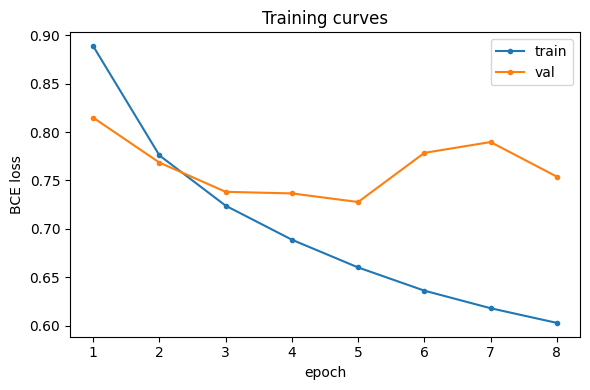

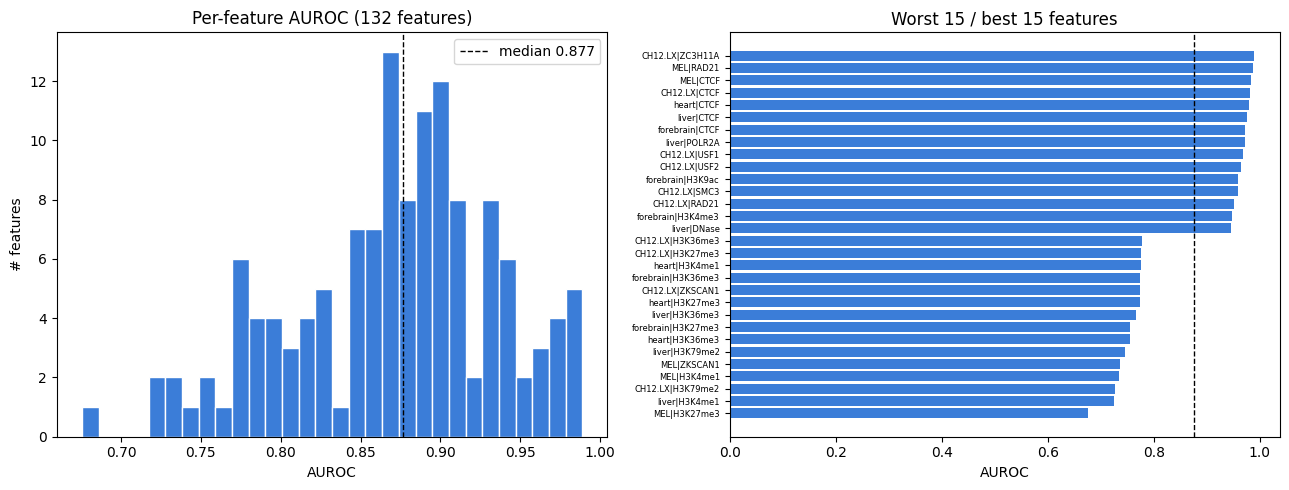

In [ ]:
# training curves
plt.figure(figsize=(6, 4))
ep_axis = range(1, len(hist["train"]) + 1)   # may be < EPOCHS if early-stopped
plt.plot(ep_axis, hist["train"], "-o", label="train", ms=3)
plt.plot(ep_axis, hist["val"],   "-o", label="val",   ms=3)
plt.xlabel("epoch"); plt.ylabel("BCE loss"); plt.title("Training curves"); plt.legend()
plt.tight_layout(); plt.show()

# per-feature AUROC: histogram (a 300-row bar chart is unreadable), plus the
# 15 best/worst features called out by name.
order = np.argsort(auroc)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].hist(auroc, bins=30, color="#3b7dd8", edgecolor="white")
ax[0].axvline(np.median(auroc), color="k", ls="--", lw=1,
              label=f"median {np.median(auroc):.3f}")
ax[0].set(xlabel="AUROC", ylabel="# features",
          title=f"Per-feature AUROC ({len(kept)} features)"); ax[0].legend()

k = min(15, len(kept))
tb = np.concatenate([order[:k], order[-k:]]) if len(kept) > 2*k else order
ax[1].barh(range(len(tb)), auroc[tb], color="#3b7dd8")
ax[1].axvline(np.median(auroc), color="k", ls="--", lw=1)
ax[1].set_yticks(range(len(tb)))
ax[1].set_yticklabels([kept[i] for i in tb], fontsize=6)
ax[1].set(xlabel="AUROC", title=f"Worst {k} / best {k} features")
plt.tight_layout(); plt.show()

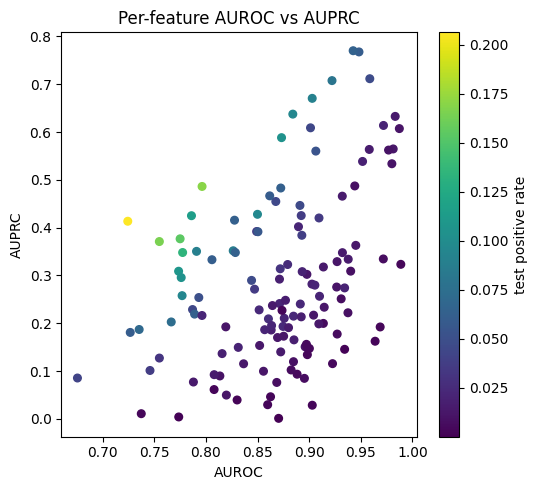

In [ ]:
# AUROC vs AUPRC -- AUPRC exposes how the model does on rare-positive features
plt.figure(figsize=(5.5, 5))
plt.scatter(auroc, auprc, c=ytrue[:, [features.index(k) for k in kept]].mean(0),
            cmap="viridis", s=30)
plt.colorbar(label="test positive rate")
plt.xlabel("AUROC"); plt.ylabel("AUPRC"); plt.title("Per-feature AUROC vs AUPRC")
plt.tight_layout(); plt.show()

### Suggested ablation
Re-run with `USE_HUMAN_WEIGHTS = False` (random trunk) and compare median AUROC.
The gap is your transfer signal: how much human motif knowledge carries to mouse.
For a longer-evolutionary-distance probe, rebuild the data with fly/worm and repeat.
This connects to your spectral-bias work &mdash; you can inspect whether the
transferred conv filters keep their frequency characteristics or relearn them.

## Appendix: the canonical Selene config (from-scratch baseline)

Selene is the original authors' library for retraining DeepSEA-style models from
a YAML config. It trains **from scratch** here (config-driven transfer with a
mismatched head needs the same conv-surgery the notebook does, so the notebook is
the cleaner route for transfer). Use this as a same-pipeline baseline.

**Install caveat:** `selene-sdk` pins older deps and compiles Cython; it does not
always build on current Colab Python. If `pip install selene-sdk` fails, that's
expected &mdash; the notebook path above does not depend on Selene.

In [ ]:
selene_yaml = '''
---
ops: [train, evaluate]
model:
  path: ./deepsea.py          # put the Selene DeepSEA class here (selene_sdk example_model.py)
  class: DeepSEA
  class_args:
    sequence_length: 1000
    n_targets: N_FEATURES     # <-- set to len(distinct_features.txt)
  non_strand_specific: mean
sampler: !obj:selene_sdk.samplers.IntervalsSampler
  reference_sequence: !obj:selene_sdk.sequences.Genome
    input_path: ./mouse_encode_data/genome/chr19.fa     # provide the FASTA(s) you used
  features: !obj:selene_sdk.utils.load_features_list
    input_path: ./mouse_encode_data/selene/distinct_features.txt
  target_path: ./mouse_encode_data/selene/mouse_peaks.bed.gz   # bgzipped + tabix-indexed
  intervals_path: ./mouse_encode_data/selene/mouse_peaks.bed   # regions to sample from
  seed: 0
  sequence_length: 1000
  center_bin_to_predict: 200
  test_holdout: [chr19]
  validation_holdout: [chr18]
  feature_thresholds: 0.5
train_model: !obj:selene_sdk.TrainModel
  batch_size: 128
  max_steps: 16000
  report_stats_every_n_steps: 2000
  n_validation_samples: 4096
  cpu_n_threads: 4
  use_cuda: true
  data_parallel: false
random_seed: 0
output_dir: ./selene_out
create_subdirectory: true
'''
with open("mouse_transfer.yml", "w") as f:
    f.write(selene_yaml.replace("N_FEATURES", str(F)))
print("wrote mouse_transfer.yml  (run with:  selene_cli.py mouse_transfer.yml )")

wrote mouse_transfer.yml  (run with:  selene_cli.py mouse_transfer.yml )
